In [1]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

seed = 42

np.random.seed(seed)
torch.manual_seed(seed)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from LSTM import Seq2SeqLSTM

In [3]:
csv_path = os.path.join('dataset', 'data_final.csv')

dataset = pd.read_csv(
    csv_path,
    index_col='Date',
    parse_dates=['Date']
)

dataset.head()

,전력량,공장 인원,is_operated,Weekend,Vacation,time_sin,time_cos,day_0,day_1,day_2,day_3,day_4,day_5,day_6,전력량_1일전,전력량_1주일전
Date,,,,,,,,,,,,,,,,
2021-01-08 00:15:00,64.0,0.0,0.0,0.0,0.0,0.065403,0.997859,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,62.0
2021-01-08 00:30:00,63.0,0.0,0.0,0.0,0.0,0.130526,0.991445,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,61.0
2021-01-08 00:45:00,63.0,0.0,0.0,0.0,0.0,0.195090,0.980785,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,61.0
2021-01-08 01:00:00,62.0,0.0,0.0,0.0,0.0,0.258819,0.965926,0.0,0.0,0.0,0.0,1.0,0.0,0.0,25.0,61.0
2021-01-08 01:15:00,87.0,0.0,0.0,0.0,0.0,0.321439,0.946930,0.0,0.0,0.0,0.0,1.0,0.0,0.0,26.0,96.0


In [4]:
idx = dataset.index

split1 = idx[int(len(idx) * 0.6)].ceil('D')
split2 = idx[int(len(idx) * 0.8)].ceil('D')

print(f'검증 셋 기준 날짜 : {split1}')
print(f'테스트 셋 기준 날짜 : {split2}')

검증 셋 기준 날짜 : 2021-06-08 00:00:00
테스트 셋 기준 날짜 : 2021-07-28 00:00:00


In [5]:
power_scaler = MinMaxScaler()
people_scaler = MinMaxScaler()

train_mask = idx < split1

power_scaler.fit(dataset.loc[train_mask, ['전력량']])
people_scaler.fit(dataset.loc[train_mask, ['공장 인원']])

dataset_scaled = dataset.copy()

dataset_scaled[['전력량']] = power_scaler.transform(
    dataset[['전력량']]
)
dataset_scaled[['전력량_1일전']] = power_scaler.transform(
    dataset[['전력량_1일전']].rename(columns={'전력량_1일전': '전력량'})
)
dataset_scaled[['전력량_1주일전']] = power_scaler.transform(
    dataset[['전력량_1주일전']].rename(columns={'전력량_1주일전': '전력량'})
)

dataset_scaled[['공장 인원']] = people_scaler.transform(
    dataset[['공장 인원']]
)

In [ ]:
FUTURE_COLS = ['Vacation', 'time_sin', 'time_cos', 
                'day_0', 'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6',
                '전력량_1일전', '전력량_1주일전',]
 
 
def make_sequences(data, future_cols=FUTURE_COLS, window_size=96, horizon=96):
    past = data.values                       
    future = data[future_cols].values        
    target = data['전력량'].values
 
    X, C, y = [], [], []
    for i in range(window_size, len(data) - horizon + 1):
        X.append(past[i - window_size: i])        
        C.append(future[i: i + horizon])         
        y.append(target[i: i + horizon])        
 
    return (
        np.array(X, dtype=np.float32),
        np.array(C, dtype=np.float32),
        np.array(y, dtype=np.float32),
    )

In [7]:
window_size = 96
horizon_size = 96

X, C, y = make_sequences(dataset_scaled, FUTURE_COLS, window_size, horizon_size)

t_start = dataset_scaled.index[window_size : len(dataset_scaled) - horizon_size + 1]  
t_end   = dataset_scaled.index[window_size + horizon_size - 1 :]   

In [8]:
train_split = t_end < split1
valid_split = (t_start >= split1) & (t_end < split2)
test_split  = t_start >= split2

X_train, C_train, y_train = X[train_split], C[train_split], y[train_split]
X_valid, C_valid, y_valid = X[valid_split], C[valid_split], y[valid_split]
X_test, C_test, y_test  = X[test_split], C[test_split], y[test_split]

print(f'훈련 셋 X : {X_train.shape}, y : {y_train.shape}')
print(f'검증 셋 X : {X_valid.shape}, y : {y_valid.shape}')
print(f'테스트 셋 X : {X_test.shape}, y : {y_test.shape}')

훈련 셋 X : (14304, 96, 16), y : (14304, 96)
검증 셋 X : (4705, 96, 16), y : (4705, 96)
테스트 셋 X : (4610, 96, 16), y : (4610, 96)


In [9]:
X_train = torch.tensor(X_train, dtype=torch.float32)
C_train = torch.tensor(C_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_valid = torch.tensor(X_valid, dtype=torch.float32)
C_valid = torch.tensor(C_valid, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
C_test = torch.tensor(C_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [10]:
train_dataset = TensorDataset(X_train, C_train, y_train)
valid_dataset = TensorDataset(X_valid, C_valid, y_valid)
test_dataset  = TensorDataset(X_test,  C_test,  y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

model = Seq2SeqLSTM(
    input_size=X_train.size(2),
    future_size=C_train.size(2),
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
).to(device)

cpu


In [ ]:
criterion = nn.L1Loss()
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',      
    factor=0.5,    
    patience=10     
)
num_epoch = 150

In [13]:
train_loss_graph = []
valid_loss_graph = []

patience = 20
best_valid_loss = float('inf')
patience_count = 0

for epoch in range(num_epoch):
    train_loss = 0.0
    valid_loss = 0.0

    model.train()

    for x, c, y in train_loader:
        x, c, y = x.to(device), c.to(device), y.to(device)
        pred = model(x, c)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()

    with torch.no_grad():
        for x, c, y in valid_loader:
            x, c, y = x.to(device), c.to(device), y.to(device)
            pred = model(x, c)
            loss = criterion(pred, y)
            valid_loss += loss.item()

    train_loss /= len(train_loader)
    valid_loss /= len(valid_loader)

    scheduler.step(valid_loss)
    
    train_loss_graph.append(train_loss)
    valid_loss_graph.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_count = 0
        best_model = copy.deepcopy(model.state_dict())
    else:
        patience_count += 1

    if epoch % 10 == 0:
        print(
            f'[epoch: {epoch}] '
            f'train loss: {train_loss:.4f}, '
            f'valid loss: {valid_loss:.4f}'
        )

    if patience_count >= patience:
        print(f'Early stopping at epoch {epoch}\n train loss: {train_loss:.4f}, '
              f'valid loss: {valid_loss:.4f}')
        break

[epoch: 0] train loss: 0.1621, valid loss: 0.0658
[epoch: 10] train loss: 0.0711, valid loss: 0.0507
[epoch: 20] train loss: 0.0564, valid loss: 0.0626
[epoch: 30] train loss: 0.0519, valid loss: 0.0741
Early stopping at epoch 36
 train loss: 0.0509, valid loss: 0.0744


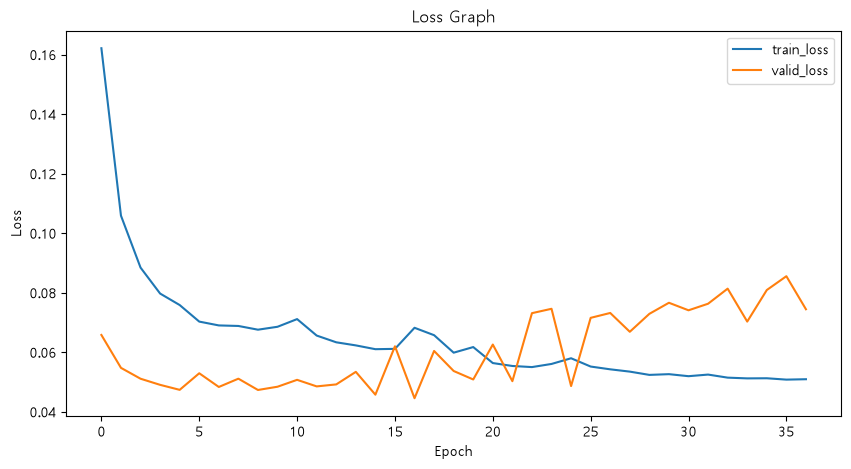

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_graph, label='train_loss')
plt.plot(valid_loss_graph, label='valid_loss')
plt.legend()
plt.title('Loss Graph')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [15]:
model.load_state_dict(best_model)
model.eval()

pred_graph = []
y_graph = []

with torch.no_grad():
    for x, c, y in test_loader:
        x, c, y = x.to(device), c.to(device), y.to(device)
        pred = model(x, c)

        pred_transform = power_scaler.inverse_transform(
            pred.detach().cpu().numpy().reshape(-1, 1)
        ).reshape(-1, horizon_size)
        y_transform = power_scaler.inverse_transform(
            y.detach().cpu().numpy().reshape(-1, 1)
        ).reshape(-1, horizon_size)

        pred_graph.append(pred_transform)
        y_graph.append(y_transform)

pred_graph = np.concatenate(pred_graph, axis=0)
y_graph = np.concatenate(y_graph, axis=0)
loss = y_graph - pred_graph

print(f'예측 shape : {pred_graph.shape}')

예측 shape : (4610, 96)


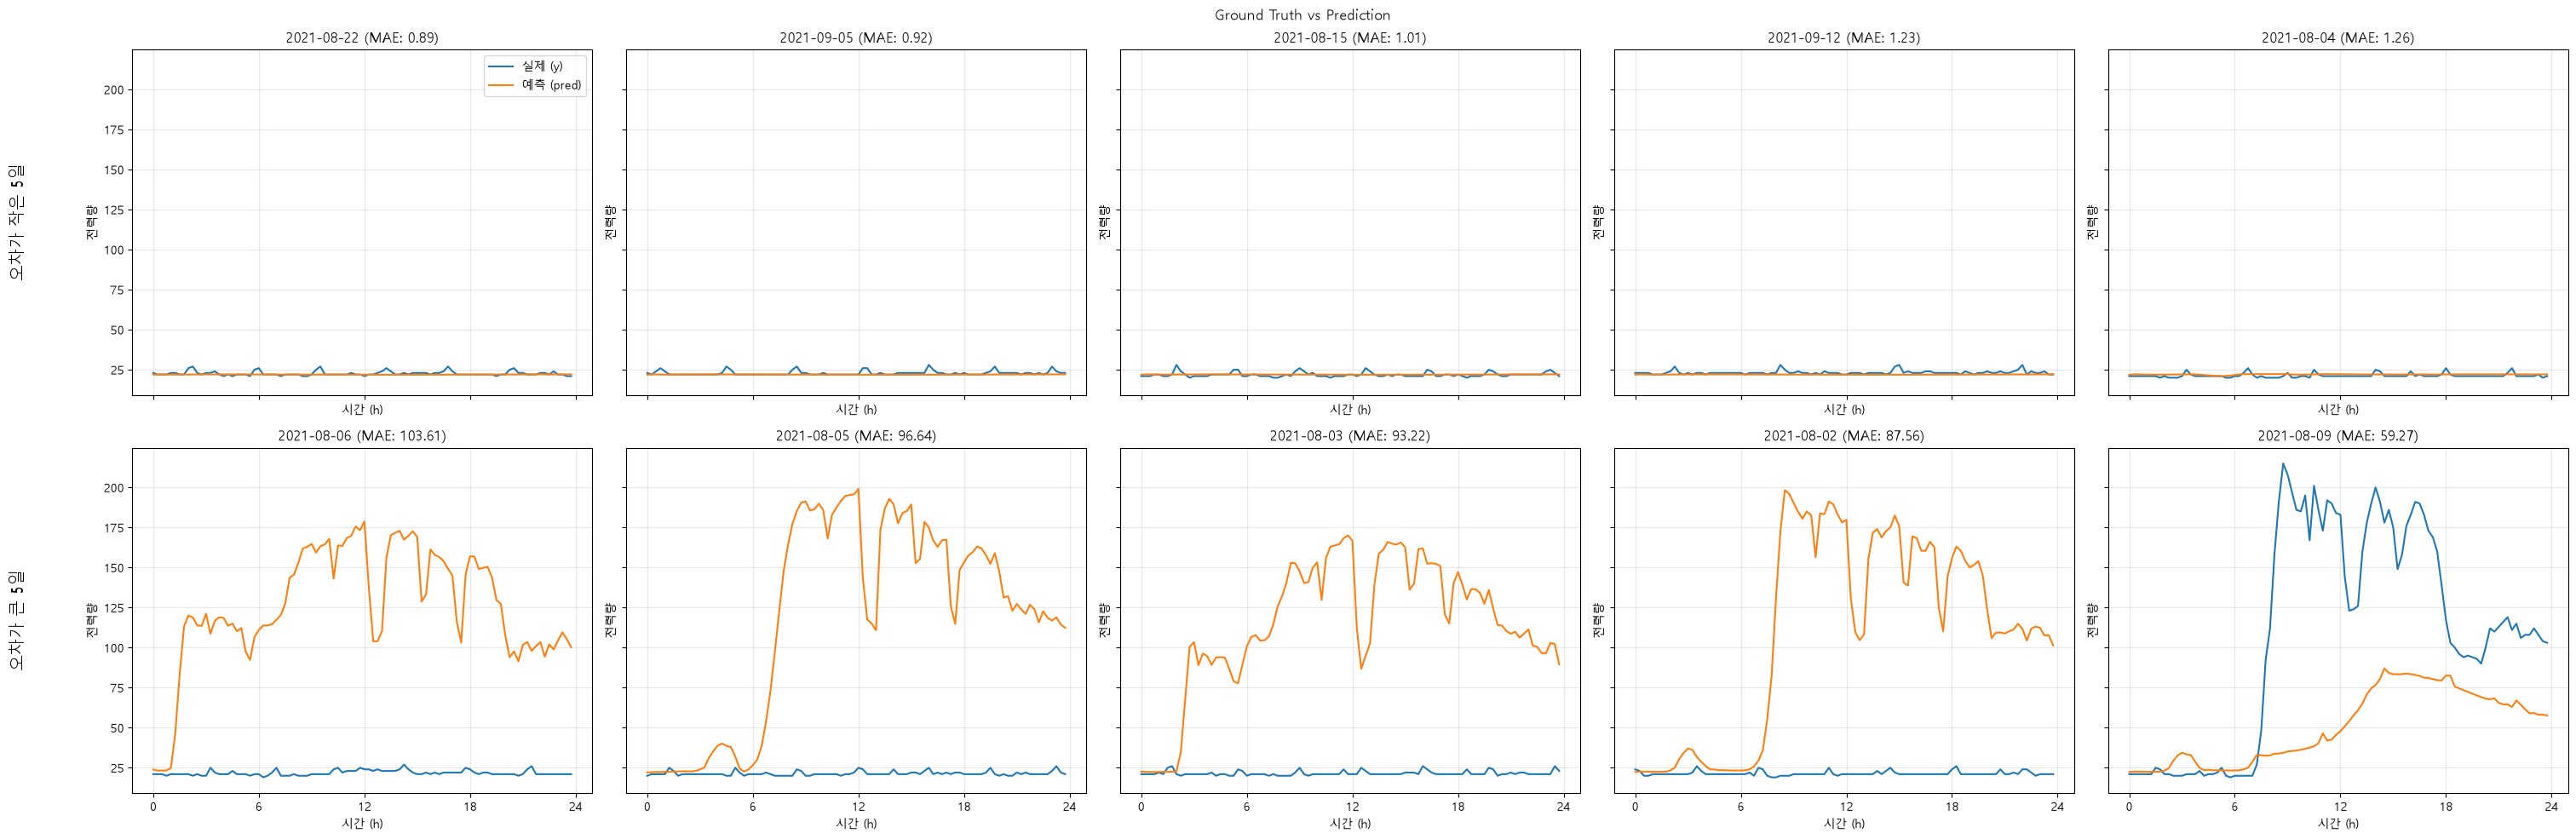

In [16]:
test_dates = t_start[test_split]
midnight = (test_dates.hour == 0) & (test_dates.minute == 0)
 
pred_d = pred_graph[midnight]              
y_d    = y_graph[midnight]               
err_d  = y_d - pred_d                       
dates  = test_dates[midnight].normalize()     
 
daily_mae = pd.Series(np.abs(err_d).mean(axis=1), index=dates).sort_index()
 
low_dates  = daily_mae.nsmallest(5).index     
high_dates = daily_mae.nlargest(5).index      
selected   = [low_dates, high_dates]
row_labels = ['오차가 작은 5일', '오차가 큰 5일']
 
hours = np.arange(horizon_size) * 15 / 60     
pos = lambda ds: daily_mae.index.get_indexer(ds)   
 
fig, axes = plt.subplots(2, 5, figsize=(30, 10), sharex=True, sharey=True)
 
for r, (row_axes, ds) in enumerate(zip(axes, selected)):
    for ax, date, i in zip(row_axes, ds, pos(ds)):
        ax.plot(hours, y_d[i], label='실제 (y)')
        ax.plot(hours, pred_d[i], label='예측 (pred)')
        ax.set_title(f"{date:%Y-%m-%d} (MAE: {daily_mae[date]:.2f})")
        ax.set_xlabel('시간 (h)')
        ax.set_ylabel('전력량')
        ax.set_xticks(range(0, 25, 6))
        ax.grid(alpha=0.3)
    row_axes[0].text(-0.25, 0.5, row_labels[r], transform=row_axes[0].transAxes,
                     rotation=90, va='center', ha='center', fontsize=14)
 
axes[0, 0].legend()
fig.suptitle('Ground Truth vs Prediction')
fig.tight_layout()
plt.show()

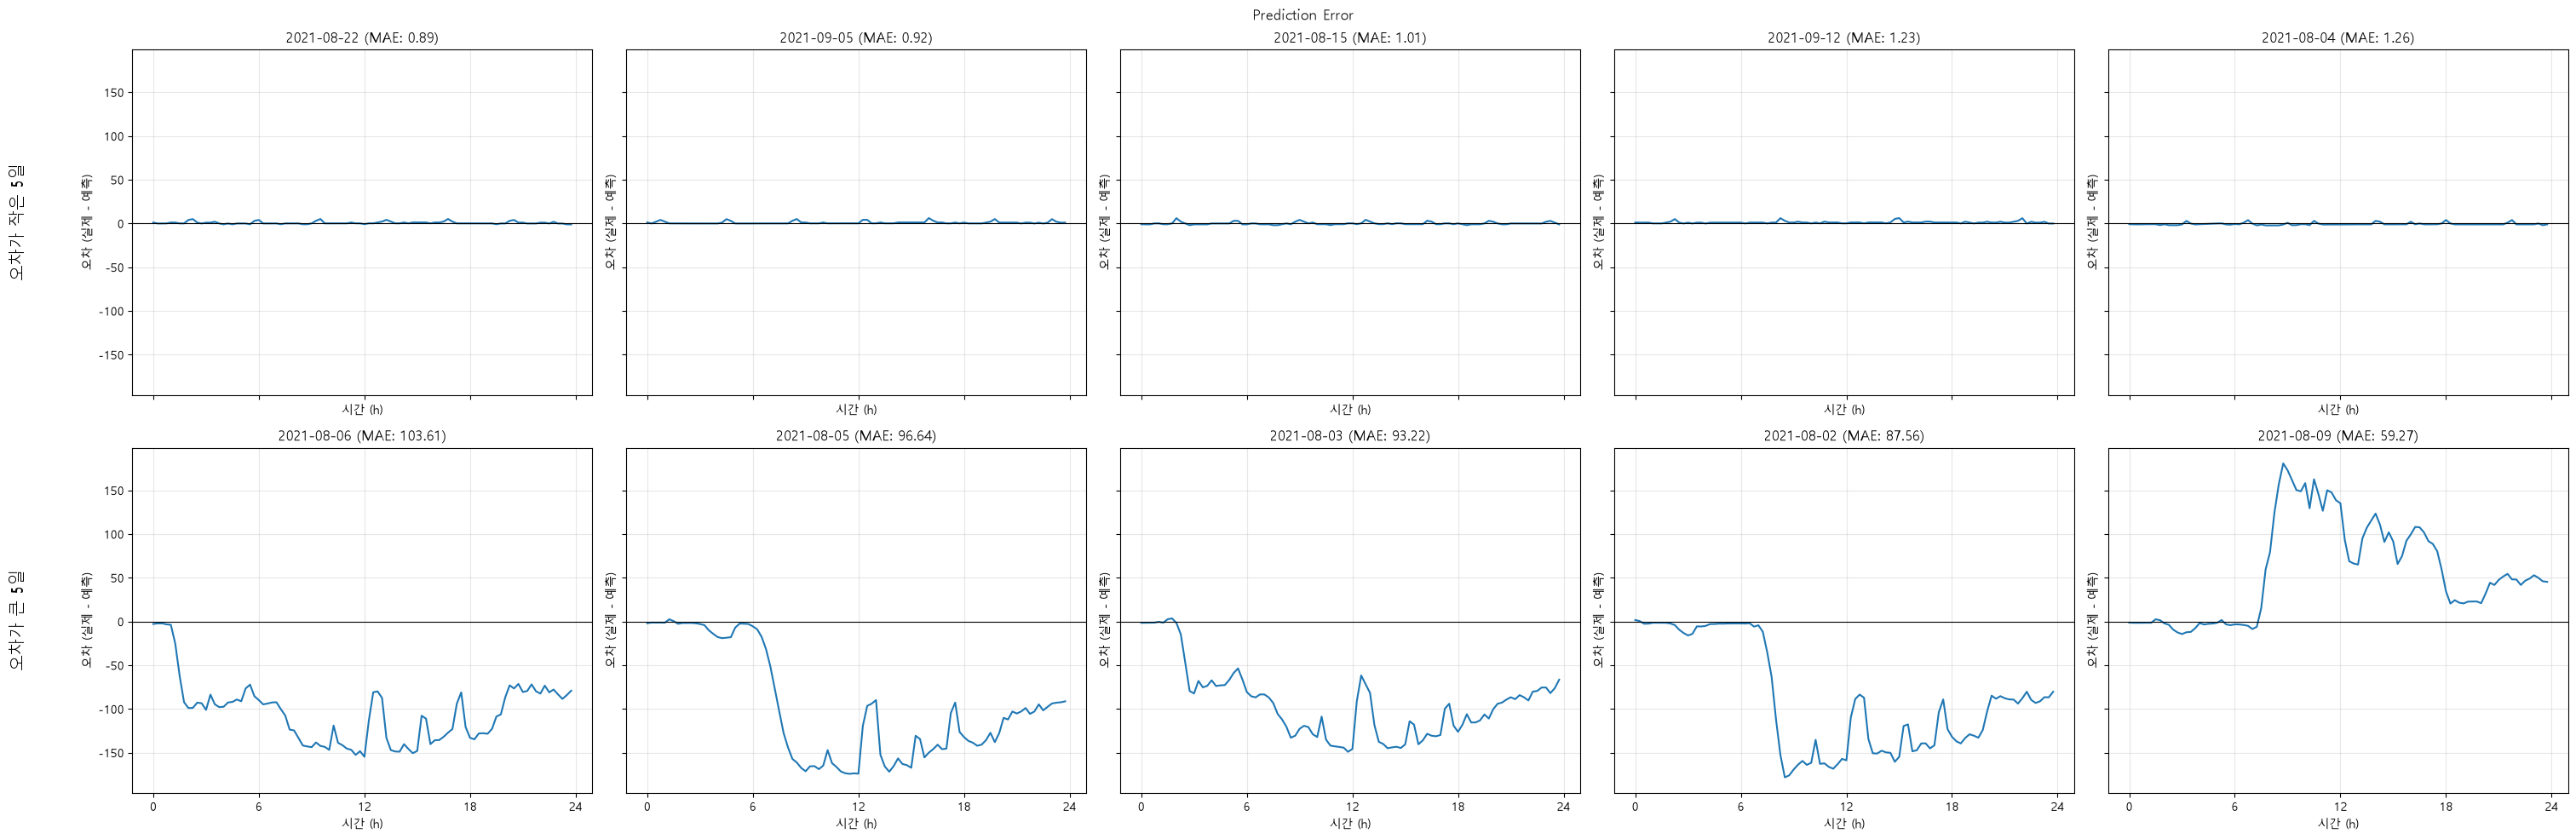

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(30, 10), sharex=True, sharey=True)
 
for r, (row_axes, ds) in enumerate(zip(axes, selected)):
    for ax, date, i in zip(row_axes, ds, pos(ds)):
        ax.plot(hours, err_d[i])
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(f"{date:%Y-%m-%d} (MAE: {daily_mae[date]:.2f})")
        ax.set_xlabel('시간 (h)')
        ax.set_ylabel('오차 (실제 - 예측)')
        ax.set_xticks(range(0, 25, 6))
        ax.grid(alpha=0.3)
    row_axes[0].text(-0.25, 0.5, row_labels[r], transform=row_axes[0].transAxes,
                     rotation=90, va='center', ha='center', fontsize=14)
 
fig.suptitle('Prediction Error')
fig.tight_layout()
plt.show()

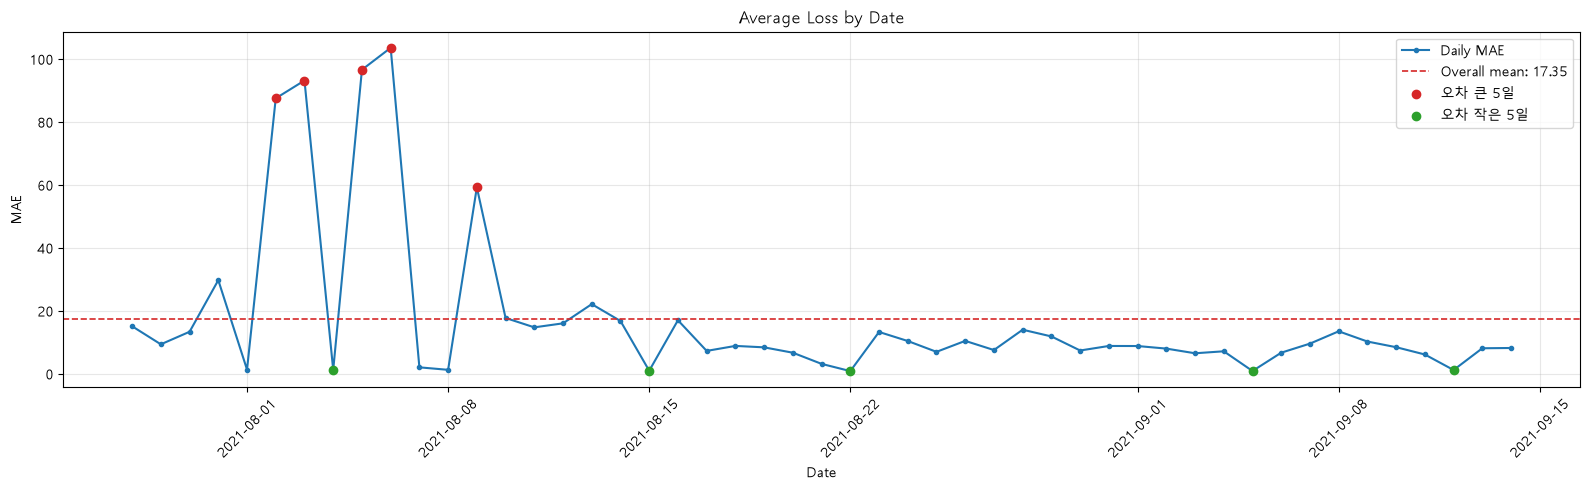

In [18]:
plt.figure(figsize=(16, 5))
plt.plot(daily_mae.index, daily_mae.values, marker='o', markersize=3,
         linewidth=1.5, label='Daily MAE')
plt.axhline(daily_mae.mean(), color='tab:red', linestyle='--', linewidth=1.2,
            label=f'Overall mean: {daily_mae.mean():.2f}')
plt.scatter(high_dates, daily_mae[high_dates], color='tab:red', zorder=3,
            label='오차 큰 5일')
plt.scatter(low_dates, daily_mae[low_dates], color='tab:green', zorder=3,
            label='오차 작은 5일')
plt.title('Average Loss by Date')
plt.xlabel('Date')
plt.ylabel('MAE')
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()